# Task 3: Occasion and Gender Classification

COSC2753 | Machine Learning

> **Historical training run:** the outputs below precede the lighting/confidence follow-up. Active checkpoints now include that follow-up. Re-running these training/export cells overwrites them. See the final appendix and [CLASSIFIER_IMPROVEMENTS.md](../CLASSIFIER_IMPROVEMENTS.md).

## 1. Introduction

This follow-up experiment compares a majority reference, HOG + HSV logistic
regression, and one plain three-block CNN per target. The goal is a model that is
effective and easy to explain. All models are trained from scratch on the
supplied training rows. The frozen group split and training-only normalization
are preserved. Literal `NA` remains a usage label.

The same CNN settings are used for every target: ordinary cross-entropy, Adam
at 0.001, batch size 64, at most 30 epochs, patience 5 and horizontal flips only.
Select on validation macro F1; within 0.01, prefer lower validation ECE, then
parameter count. The majority reference cannot win.

Earlier test results have already been seen. This is explicitly a follow-up
after test exposure, not a fresh untouched holdout. No follow-up test scores are
used to tune or select models. See [the simplification record](../docs/SIMPLIFICATION_EXPERIMENT.md).

## 2. Library Imports and Setup

In [1]:
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import torch

from app.server.utils.modeling import SimpleCNN
from scripts.classification import make_loader, train_cnn, predict_cnn, comparison_row
from app.server.utils.classifier import FashionClassifier
from app.server.utils.handcrafted import DEFAULT_FEATURE_CONFIG, handcrafted_feature
from evaluation import calibration_table, expected_calibration_error, high_confidence_errors, ordered_estimator_probabilities, saved_model_robustness, select_validation_candidate, subgroup_metrics
from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame
torch.set_num_threads(4)
seed_everything(SEED)
torch.manual_seed(SEED)
DEVICE = select_torch_device()
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
def supported_macro_f1(truth, predictions):
    return f1_score(truth, predictions, labels=np.unique(truth), average='macro', zero_division=0)
DEVICE


Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

## 3. Shared Split and Target-Specific Filtering

In [2]:
frames = {
    target: {split: task_frame(target, split) for split in ('train', 'validation', 'test')}
    for target in ('gender', 'usage')
}
pd.DataFrame({
    (target, split): frame[target].value_counts()
    for target, split_frames in frames.items() for split, frame in split_frames.items()
}).fillna(0).astype(int)

gender                   usage                 
              train validation  test  train validation  test
Boys            529        155   130      0          0     0
Casual            0          0     0  20815       4511  4309
Ethnic            0          0     0   1786        369   415
Formal            0          0     0   1610        355   335
Girls           453         81   111      0          0     0
Home              0          0     0      1          0     0
Men           14610       3158  3144      0          0     0
NA                0          0     0     40          8    23
Party             0          0     0      9          2     2
Smart Casual      0          0     0     43          5     7
Sports            0          0     0   2729        586   625
Travel            0          0     0     17          6     2
Unisex         1453        330   297      0          0     0
Women         10006       2118  2036      0          0     0

Only genuinely blank target values are excluded from that target's rows. Literal `NA` remains a valid usage class. The frozen split yields 27,051/5,842/5,718 gender rows and 27,050/5,842/5,718 usage rows. There are five gender and nine usage labels in training; every label present in validation or test is represented in training. The one blank usage row is in training. The shared product-group assignments are retained.

## 4. Gender and Usage EDA

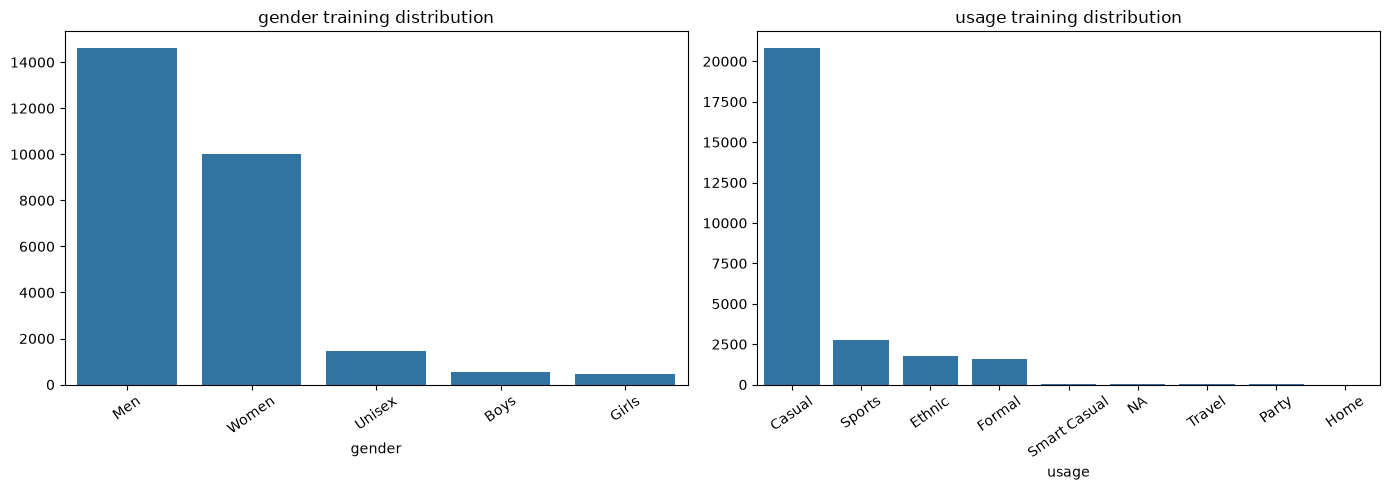

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for target, axis in zip(('gender', 'usage'), axes):
    counts = frames[target]['train'][target].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axis)
    axis.set_title(f'{target} training distribution')
    axis.tick_params(axis='x', rotation=35)
plt.tight_layout()

In [4]:
pd.crosstab(frames['usage']['train']['articleType'], frames['usage']['train']['usage'], normalize='index').head(25).style.background_gradient(cmap='Greens')

usage,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
articleType,,,,,,,,,
Accessory Gift Set,0.200000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
Backpacks,0.865979,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.113402,0.020619
Bangle,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Basketballs,0.222222,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.777778,0.000000
Belts,0.819469,0.000000,0.180531,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Blazers,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Body Wash and Scrub,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Booties,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### 4.1 Observations

**Gender:** Men (14,610) and Women (10,006) dominate training; Unisex (1,453), Boys (529) and Girls (453) are less frequent. The largest-to-smallest ratio is about 32:1. These are catalogue audience labels, not an inference about a person's identity. Product-type associations may act as shortcuts, but a label crosstab cannot show which features the image model actually uses.

**Usage:** Casual has 20,815 training rows, compared with 2,729 Sports rows. Home (1), Party (9), Travel (17), Smart Casual (43) and NA (40) have very limited support. Category/usage associations motivate investigation of catalogue priors; mixed labels within a category do not by themselves establish visual ambiguity. Literal `NA` is retained for data fidelity and evaluated like any supported class.

**Simplification hypothesis:** Compare one ordinary-loss plain CNN with balanced HOG+HSV logistic regression for each target. Macro F1, not accuracy alone, guides selection under severe imbalance.

## 5. Majority Baselines

In [5]:
baseline_rows, majority_models, majority_probabilities = [], {}, {}
for target in ('gender', 'usage'):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_frame), 1)), train_frame[target])
    labels = sorted(train_frame[target].unique())
    prediction = dummy.predict(np.zeros((len(validation_frame), 1)))
    majority_models[target] = dummy
    majority_probabilities[target] = ordered_estimator_probabilities(dummy, np.zeros((len(validation_frame), 1)), labels)
    baseline_rows.append({
        'target': target, 'accuracy': accuracy_score(validation_frame[target], prediction),
        'macro_f1': supported_macro_f1(validation_frame[target], prediction),
    })
baseline_results = pd.DataFrame(baseline_rows).set_index('target')
baseline_results

,accuracy,macro_f1
target,,
gender,0.540568,0.140356
usage,0.772167,0.108930


## 6. HOG + HSV Classical Baselines

In [6]:
feature_cache = {}
def handcrafted_feature_row(row):
    if row.id in feature_cache: return feature_cache[row.id]
    with Image.open(row.image_path) as source:
        feature_cache[row.id] = handcrafted_feature(source, DEFAULT_FEATURE_CONFIG)
    return feature_cache[row.id]

classical_rows, classical_models, classical_probabilities = [], {}, {}
for target in ('gender', 'usage'):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    train_features = np.vstack([handcrafted_feature_row(row) for row in train_frame.itertuples()])
    validation_features = np.vstack([handcrafted_feature_row(row) for row in validation_frame.itertuples()])
    baseline = make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs'),
    ).fit(train_features, train_frame[target])
    labels = sorted(train_frame[target].unique())
    prediction = baseline.predict(validation_features)
    classical_models[target] = baseline
    classical_probabilities[target] = ordered_estimator_probabilities(baseline, validation_features, labels)
    classical_rows.append({'target': target, 'accuracy': accuracy_score(validation_frame[target], prediction), 'macro_f1': supported_macro_f1(validation_frame[target], prediction)})
classical_results = pd.DataFrame(classical_rows).set_index('target')
classical_results

,accuracy,macro_f1
target,,
gender,0.792708,0.625301
usage,0.769086,0.418500


## 7. Shared image pipeline

Use the same resize, frozen normalization, and training-only horizontal flips for both targets. The dataset is defined once in [classification.py](../scripts/classification.py).

In [7]:
print('Input size (width, height):', IMAGE_SIZE)
print('Training augmentation: horizontal flip only')


Input size (width, height): (96, 128)
Training augmentation: horizontal flip only


## 8. Plain CNN architecture

| Stage | Operation | Purpose |
|---|---|---|
| Input | RGB, 128 high x 96 wide; frozen training normalization | Consistent input |
| Block 1 | Conv 3x3, 32 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Local edges |
| Block 2 | Conv 3x3, 64 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Combine patterns |
| Block 3 | Conv 3x3, 128 channels -> BatchNorm -> ReLU -> MaxPool 2x2 | Higher-level features |
| Head | Adaptive average pool 2x2 -> Flatten -> Dense 128 -> ReLU -> Dropout 0.2 -> output | Predict target logits |

There are no residual connections or pretrained weights. The single definition
in [modeling.py](../app/server/utils/modeling.py) is shared with API inference.
The table describes the intended roles; it is not evidence of what each filter learned.

In [8]:
example_model = SimpleCNN(5)
print(example_model)
print('Gender parameters:', sum(p.numel() for p in example_model.parameters()))


SimpleCNN(
  (layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(2, 2))
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=512, out_features=128, bias=True)
    (15): ReLU()

## 9. Train one CNN

The short shared [training loop](../scripts/classification.py) performs the same
steps each epoch: predict, compute ordinary cross-entropy, backpropagate and update
with Adam; then evaluate without gradients. Save the state whenever validation
macro F1 improves and stop after five non-improving epochs (30 maximum).
There is no loss-mode search, scheduler or per-target hyperparameter tuning.
Training F1 uses augmented images and training-mode layers, so its gap from
validation F1 is descriptive rather than an identical-conditions comparison.

In [9]:
def train_target(target):
    seed_everything(SEED)
    torch.manual_seed(SEED)
    train_frame = frames[target]['train']
    validation_frame = frames[target]['validation']
    labels = sorted(train_frame[target].unique())
    mapping = {label: index for index, label in enumerate(labels)}
    train_loader = make_loader(train_frame, target, labels, normalisation, training=True)
    validation_loader = make_loader(validation_frame, target, labels, normalisation)
    cnn = SimpleCNN(len(labels))
    cnn, history = train_cnn(cnn, train_loader, validation_loader, DEVICE,
                             max_epochs=30, patience=5)
    history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'],
                 title=f'{target}: plain CNN learning curve', figsize=(8, 4))
    plt.show()
    history.to_csv(ROOT / 'models' / f'{target}_cnn_history.csv', index=False)
    return cnn, labels, mapping, history


## 10. Gender Classifier

Epoch 01: train F1=0.3002, validation F1=0.3113, 24.9s


Epoch 02: train F1=0.3603, validation F1=0.3723, 24.7s


Epoch 03: train F1=0.4562, validation F1=0.5151, 24.8s


Epoch 04: train F1=0.5310, validation F1=0.4925, 24.7s


Epoch 05: train F1=0.5621, validation F1=0.4575, 24.7s


...

Epoch 21: train F1=0.7241, validation F1=0.6653, 24.8s


Epoch 22: train F1=0.7301, validation F1=0.6543, 24.8s


Epoch 23: train F1=0.7344, validation F1=0.6876, 24.8s


Epoch 24: train F1=0.7379, validation F1=0.6972, 24.8s


Epoch 25: train F1=0.7403, validation F1=0.6990, 24.8s


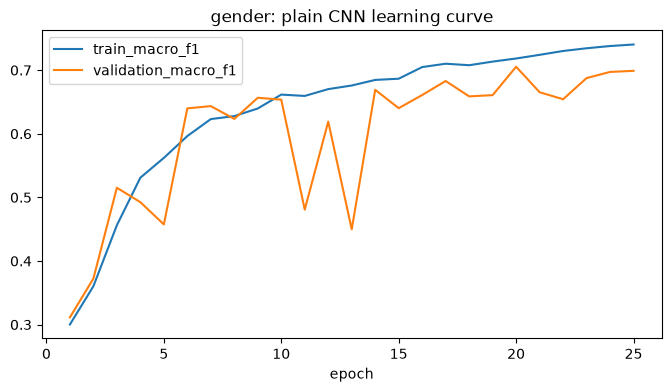

,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.540568,0.140356,0.459432,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.792708,0.625301,0.085586,6425,0,True
cnn_ordinary,simple_cnn,0.867511,0.705344,0.017907,160005,25,True


Selected gender method 'cnn_ordinary' before internal-test evaluation.


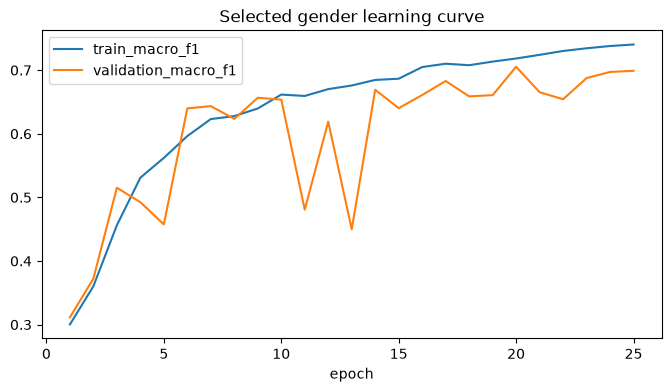

In [10]:
def compare_and_select_target(target, cnn_result):
    cnn, labels, mapping, cnn_history = cnn_result
    validation_frame = frames[target]['validation']
    truth = np.asarray([mapping[label] for label in validation_frame[target]])
    loader = make_loader(validation_frame, target, labels, normalisation)
    probabilities = predict_cnn(cnn, loader, DEVICE)
    classical = classical_models[target]
    comparison = pd.DataFrame([comparison_row('majority', 'reference_only', truth, majority_probabilities[target], 1, eligible=False), comparison_row('hog_hsv_logistic_regression', 'hog_hsv_logistic_regression', truth, classical_probabilities[target], classical[-1].coef_.size + classical[-1].intercept_.size), comparison_row('cnn_ordinary', 'simple_cnn', truth, probabilities, sum((p.numel() for p in cnn.parameters())), epochs=len(cnn_history))]).set_index('method')
    method = select_validation_candidate(comparison.loc[comparison.eligible_for_selection])
    model_type = comparison.loc[method, 'model_type']
    if model_type == 'simple_cnn':
        model = cnn.cpu()
        history = cnn_history
        loss_mode = 'ordinary'
    else:
        model = classical
        history = pd.DataFrame([{'method': method, **comparison.loc[method].to_dict()}])
        loss_mode = None
        cnn.cpu()
    return {'method': method, 'model_type': model_type, 'loss_mode': loss_mode, 'model': model, 'labels': labels, 'mapping': mapping, 'history': history, 'best_f1': float(comparison.loc[method, 'validation_macro_f1']), 'comparison': comparison}
gender_cnn = train_target('gender')
gender_selection = compare_and_select_target('gender', gender_cnn)
gender_model, gender_labels, gender_mapping = (gender_selection['model'], gender_selection['labels'], gender_selection['mapping'])
gender_history, gender_best_f1, gender_comparison = (gender_selection['history'], gender_selection['best_f1'], gender_selection['comparison'])
GENDER_SELECTED_METHOD, GENDER_SELECTED_MODEL_TYPE, GENDER_SELECTED_LOSS_MODE = (gender_selection['method'], gender_selection['model_type'], gender_selection['loss_mode'])
display(gender_comparison)
print(f'Selected gender method {GENDER_SELECTED_METHOD!r} before internal-test evaluation.')
if 'epoch' in gender_history.columns:
    gender_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Selected gender learning curve')
    plt.show()


### 10.1 Gender analysis

Validation macro F1: majority 0.1404, HOG+HSV 0.6253, plain CNN 0.7053. The predeclared selection rule chooses **cnn_ordinary** (selection-table validation ECE 0.0179).

The CNN's best epoch is 20; it runs for 25 epochs. At that epoch training/validation macro F1 are 0.7183/0.7053, a gap of 0.0130. Training uses flips, dropout and batch statistics, so these are different evaluation conditions. The full CNN history is retained even when the classical model wins.

## 11. Occasion/Usage Classifier

Epoch 01: train F1=0.1379, validation F1=0.2734, 24.9s


Epoch 02: train F1=0.2400, validation F1=0.3068, 24.9s


Epoch 03: train F1=0.2696, validation F1=0.3025, 24.8s


Epoch 04: train F1=0.2874, validation F1=0.3511, 24.8s


Epoch 05: train F1=0.2983, validation F1=0.3593, 24.9s


...

Epoch 13: train F1=0.3340, validation F1=0.3705, 24.9s


Epoch 14: train F1=0.3364, validation F1=0.3871, 24.9s


Epoch 15: train F1=0.3373, validation F1=0.3459, 24.9s


Epoch 16: train F1=0.3403, validation F1=0.3857, 24.9s


Epoch 17: train F1=0.3431, validation F1=0.3877, 24.8s


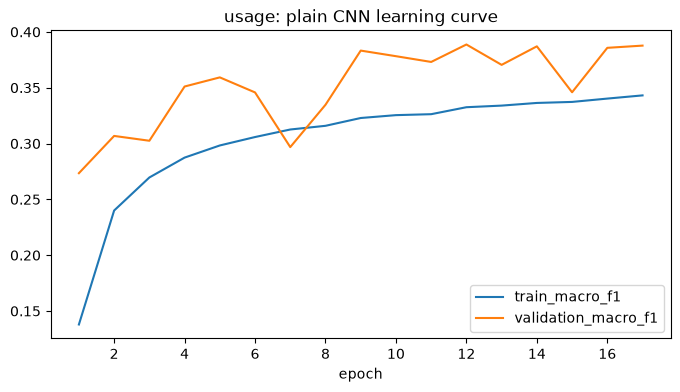

,model_type,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,eligible_for_selection
method,,,,,,,
majority,reference_only,0.772167,0.108930,0.227833,1,0,False
hog_hsv_logistic_regression,hog_hsv_logistic_regression,0.769086,0.418500,0.103711,11565,0,True
cnn_ordinary,simple_cnn,0.875385,0.388722,0.040339,160521,17,True


Selected usage method 'hog_hsv_logistic_regression' before internal-test evaluation.


In [11]:
usage_cnn = train_target('usage')
usage_selection = compare_and_select_target('usage', usage_cnn)
usage_model, usage_labels, usage_mapping = (usage_selection['model'], usage_selection['labels'], usage_selection['mapping'])
usage_history, usage_best_f1, usage_comparison = (usage_selection['history'], usage_selection['best_f1'], usage_selection['comparison'])
USAGE_SELECTED_METHOD, USAGE_SELECTED_MODEL_TYPE, USAGE_SELECTED_LOSS_MODE = (usage_selection['method'], usage_selection['model_type'], usage_selection['loss_mode'])
display(usage_comparison)
print(f'Selected usage method {USAGE_SELECTED_METHOD!r} before internal-test evaluation.')
if 'epoch' in usage_history.columns:
    usage_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Selected usage learning curve')
    plt.show()


### 11.1 Usage analysis

Validation macro F1: majority 0.1089, HOG+HSV 0.4185, plain CNN 0.3887. The predeclared selection rule chooses **hog_hsv_logistic_regression** (validation ECE 0.1037).

The CNN's best epoch is 12; it runs for 17 epochs. At that epoch training/validation macro F1 are 0.3325/0.3887, a gap of -0.0562. Training uses flips, dropout and batch statistics, so these are different evaluation conditions. The full CNN history is retained even when the classical model wins.

Selection illustrates why accuracy alone is misleading here: the plain CNN has
validation accuracy 0.8754 versus 0.7691 for HOG+HSV, but its macro F1 is lower
(0.3887 versus 0.4185). It is also better calibrated on validation (ECE 0.0403
versus 0.1037). The chosen HOG model trades accuracy and calibration for the
predeclared equal-class macro-F1 objective; it does not win every criterion.

## 12. Follow-up internal-test evaluation

Both target methods are selected on validation before this section. Earlier test results have already been seen; this is a disclosed follow-up, not a fresh untouched holdout.

In [12]:
@torch.inference_mode()
def evaluate_target(target, model, model_type, labels, label_to_index):
    test_frame = frames[target]['test']
    truth = np.asarray([label_to_index[label] for label in test_frame[target]])
    if model_type == 'simple_cnn':
        loader = make_loader(test_frame, target, labels, normalisation)
        probabilities = predict_cnn(model, loader, DEVICE)
        model.cpu()
    else:
        features = np.vstack([handcrafted_feature_row(row) for row in test_frame.itertuples()])
        probabilities = ordered_estimator_probabilities(model, features, labels)
    predictions = probabilities.argmax(1)
    metrics = {'accuracy': accuracy_score(truth, predictions), 'ece': expected_calibration_error(truth, probabilities), 'macro_f1': supported_macro_f1(truth, predictions)}
    return metrics, truth, predictions, probabilities, model

gender_metrics, gender_truth, gender_predictions, gender_probabilities, gender_model = evaluate_target('gender', gender_model, GENDER_SELECTED_MODEL_TYPE, gender_labels, gender_mapping)
usage_metrics, usage_truth, usage_predictions, usage_probabilities, usage_model = evaluate_target('usage', usage_model, USAGE_SELECTED_MODEL_TYPE, usage_labels, usage_mapping)
pd.DataFrame([gender_metrics, usage_metrics], index=['gender', 'usage'])


,accuracy,ece,macro_f1
gender,0.853795,0.024774,0.672534
usage,0.770549,0.098414,0.363919



GENDER
Absent from this test partition: []
              precision    recall  f1-score   support

        Boys       0.51      0.69      0.59       130
       Girls       0.52      0.58      0.55       111
         Men       0.86      0.95      0.90      3144
      Unisex       0.64      0.37      0.47       297
       Women       0.93      0.80      0.86      2036

    accuracy                           0.85      5718
   macro avg       0.69      0.68      0.67      5718
weighted avg       0.86      0.85      0.85      5718



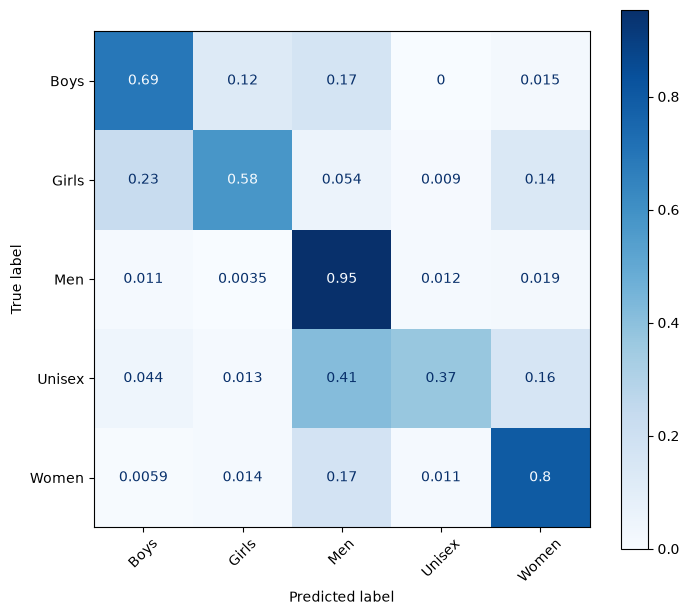

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.268015,0.000000,8
"(0.3, 0.4]",0.361746,0.284091,88
"(0.4, 0.5]",0.453542,0.407240,221
"(0.5, 0.6]",0.552184,0.530201,298
"(0.6, 0.7]",0.651296,0.615836,341
"(0.7, 0.8]",0.751994,0.696386,415
"(0.8, 0.9]",0.855091,0.805511,617


,id,articleType,gender,image_path,truth,prediction,confidence
4921,43306,Shirts,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.997690
5619,50815,Wallets,Unisex,D:\khoile\programs\fashion-intelligence-classi...,Unisex,Women,0.997689
5238,46680,Perfume and Body Mist,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.997674
1048,9929,Tshirts,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.997344
4986,43924,Tops,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.996176
2939,25795,Suspenders,Men,D:\khoile\programs\fashion-intelligence-classi...,Men,Women,0.995930
4959,43516,Tops,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.995520
2217,19330,Jackets,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.994560
2337,20214,Sweatshirts,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.994275
5233,46674,Perfume and Body Mist,Women,D:\khoile\programs\fashion-intelligence-classi...,Women,Men,0.993712


,articleType,support,accuracy,macro_f1
5,Casual Shoes,438,0.819635,0.325921
19,Sandals,118,0.813559,0.335154
21,Shorts,90,0.611111,0.399406
33,Watches,312,0.685897,0.399437
0,Backpacks,110,0.763636,0.407970
4,Caps,42,0.452381,0.416720
9,Flip Flops,118,0.711864,0.437535
6,Deodorant,34,0.764706,0.437797
22,Socks,89,0.842697,0.492203
26,Sweatshirts,41,0.804878,0.513889



USAGE
Absent from this test partition: ['Home']
              precision    recall  f1-score   support

      Casual       0.93      0.77      0.84      4309
      Ethnic       0.68      0.86      0.76       415
      Formal       0.48      0.79      0.60       335
          NA       0.20      0.04      0.07        23
       Party       0.00      0.00      0.00         2
Smart Casual       0.05      0.14      0.07         7
      Sports       0.45      0.76      0.57       625
      Travel       0.00      0.00      0.00         2

    accuracy                           0.77      5718
   macro avg       0.35      0.42      0.36      5718
weighted avg       0.83      0.77      0.79      5718



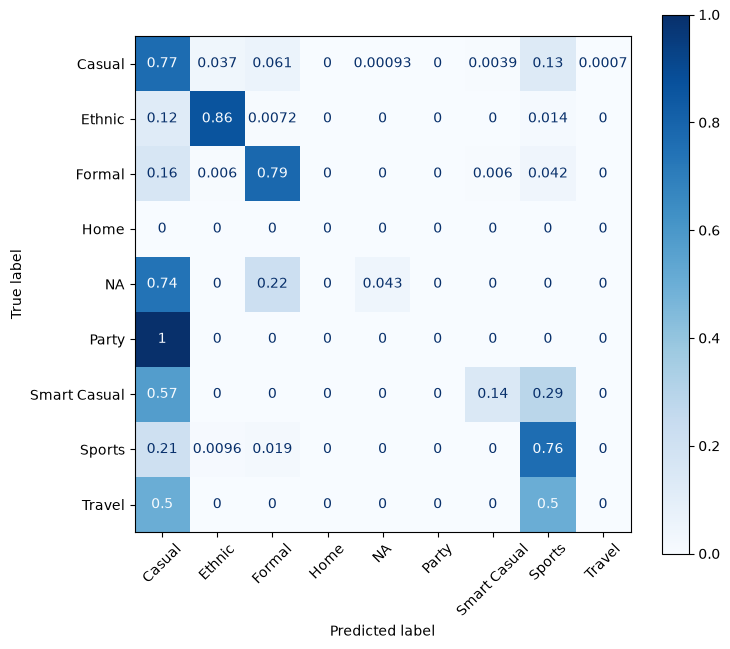

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.269593,0.000000,1
"(0.3, 0.4]",0.374908,0.384615,13
"(0.4, 0.5]",0.464400,0.430233,86
"(0.5, 0.6]",0.549693,0.477218,417
"(0.6, 0.7]",0.651813,0.609914,464
"(0.7, 0.8]",0.754252,0.637631,574
"(0.8, 0.9]",0.855947,0.737299,807


,id,articleType,usage,image_path,truth,prediction,confidence
2926,25733,Belts,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,1.000000
5296,47207,Formal Shoes,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999982
3746,32378,Dresses,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Ethnic,0.999974
4032,34585,Dresses,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Ethnic,0.999962
1183,11144,Shirts,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999959
1182,11143,Shirts,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999959
4852,42939,Belts,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999931
5145,45622,Formal Shoes,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999903
1520,13558,Flats,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999892
5455,49357,Casual Shoes,Casual,D:\khoile\programs\fashion-intelligence-classi...,Casual,Formal,0.999879


,articleType,support,accuracy,macro_f1
32,Wallets,125,0.848000,0.268015
5,Casual Shoes,438,0.557078,0.271374
7,Dresses,58,0.413793,0.292683
10,Formal Shoes,114,0.780702,0.296667
19,Sandals,118,0.872881,0.310709
11,Handbags,186,0.946237,0.324125
22,Socks,89,0.415730,0.329399
33,Watches,312,0.852564,0.367940
20,Shirts,423,0.775414,0.421369
18,Perfume and Body Mist,96,0.781250,0.438596


In [13]:
for target, truth, predictions, probabilities, labels in [
    ('gender', gender_truth, gender_predictions, gender_probabilities, gender_labels),
    ('usage', usage_truth, usage_predictions, usage_probabilities, usage_labels),
]:
    print(f'\n{target.upper()}')
    label_indices = np.arange(len(labels))
    supported_indices = np.unique(truth)
    print('Absent from this test partition:', [label for i, label in enumerate(labels) if i not in supported_indices])
    print(classification_report(
        truth, predictions, labels=supported_indices,
        target_names=[labels[i] for i in supported_indices], zero_division=0,
    ))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        truth, predictions, labels=label_indices, display_labels=labels, normalize='true',
        ax=ax, cmap='Blues', xticks_rotation=45,
    )
    plt.show()
    display(calibration_table(truth, probabilities))
    display(high_confidence_errors(frames[target]['test'], target, labels, truth, predictions, probabilities))
    truth_labels = [labels[index] for index in truth]
    prediction_labels = [labels[index] for index in predictions]
    display(subgroup_metrics(frames[target]['test'], truth_labels, prediction_labels, group_column='articleType', minimum_support=30))

### 12.1 Comparative failure analysis

**Gender**

Full CPU test accuracy is 0.8538, supported-label macro F1 0.6725, and ECE 0.0248. The notebook test cells run on CUDA; the separate CPU verification allows and records small numerical differences, with a maximum permitted absolute metric delta of 0.001.

The weakest supported labels include Unisex (F1 0.468, n=297), Girls (F1 0.547, n=111), Boys (F1 0.588, n=130). Small class counts make these estimates noisy. The class and subgroup tables describe errors; they do not establish which visual cues caused them.

On the same fixed 300-image robustness sample, macro F1 is: clean 0.5586, brightness_0.8 0.3864, brightness_1.2 0.5341, gaussian_blur_0.7 0.4824. These are sample scores, not full-test scores. The selected checkpoint occupies 0.62 MiB. CPU timing is machine-dependent and includes image preprocessing; it is not an end-to-end web benchmark.

**Usage**

Full CPU test accuracy is 0.7705, supported-label macro F1 0.3639, and ECE 0.0984. The selected HOG+HSV pipeline runs on CPU. Separate CPU verification reproduces the saved checkpoint metrics; exact differences are retained in the verification record.

The weakest supported labels include Party (F1 0.000, n=2), Travel (F1 0.000, n=2), NA (F1 0.071, n=23). Small class counts make these estimates noisy. The class and subgroup tables describe errors; they do not establish which visual cues caused them.

On the same fixed 300-image robustness sample, macro F1 is: clean 0.5906, brightness_0.8 0.5922, brightness_1.2 0.5836, gaussian_blur_0.7 0.6068. These are sample scores, not full-test scores. The selected checkpoint occupies 0.11 MiB. CPU timing is machine-dependent and includes image preprocessing; it is not an end-to-end web benchmark.

Excluding only the 23 literal-NA ground-truth rows gives macro F1 0.4065 on 5695 rows. This is reporting-only sensitivity: no refit, no removal of NA predictions, and no change to deployment labels.

**What these results imply:** Gender's improved clean score does not remove its
weakness on Unisex, Girls and Boys. Darkening reduces gender sample macro F1 from
0.5586 to 0.3864 (about 0.1721), and blur reduces it to 0.4824. These are meaningful
sensitivities despite the low clean-test ECE. Casual Shoes illustrate subgroup
imbalance: gender accuracy is 0.8196 but subgroup macro F1 is only 0.3259 across
438 images. Those statistics alone cannot identify the learned visual cues.

Usage has a different limitation: the highest-confidence test bin averages
0.9738 confidence but only 0.8704 accuracy across 3,356 examples. High confidence
should not be treated as a reliable probability of correctness. Party and Travel
each have two test examples; Home has none, so no test performance for Home can
be established. The change from 0.3639 to 0.4065 after excluding NA truth rows is
a change in the reported population, not a model improvement; NA is not
negligible in an equal-class average. Small increases on the fixed blur sample
do not establish a robust improvement without uncertainty estimates or repetition.

## 13. Save Both Selected Models

In [14]:
def save_classifier(target, model, model_type, labels, method, loss_mode, comparison, test_metrics):
    path = ROOT / 'models' / f'{target}_model.pt'
    validation_metrics = {key: float(comparison.loc[method, key]) for key in ('validation_accuracy', 'validation_macro_f1', 'validation_ece')}
    if model_type == 'simple_cnn':
        checkpoint = {'model_type': model_type, 'target': target, 'labels': labels, 'state_dict': model.state_dict(), 'mean': normalisation['mean'], 'std': normalisation['std'], 'image_size': list(IMAGE_SIZE), 'dropout': 0.2, 'loss_mode': loss_mode}
    else:
        checkpoint = {'model_type': model_type, 'target': target, 'labels': labels, 'estimator': model, 'feature_config': DEFAULT_FEATURE_CONFIG}
    checkpoint.update({'selection_metric': 'validation_macro_f1', 'best_validation_macro_f1': validation_metrics['validation_macro_f1'], 'validation_metrics': validation_metrics, 'test_metrics': test_metrics, 'seed': SEED})
    checkpoint['experiment'] = 'simple_cnn_v1'
    torch.save(checkpoint, path)
    return path

gender_path = save_classifier('gender', gender_model, GENDER_SELECTED_MODEL_TYPE, gender_labels, GENDER_SELECTED_METHOD, GENDER_SELECTED_LOSS_MODE, gender_comparison, gender_metrics)
usage_path = save_classifier('usage', usage_model, USAGE_SELECTED_MODEL_TYPE, usage_labels, USAGE_SELECTED_METHOD, USAGE_SELECTED_LOSS_MODE, usage_comparison, usage_metrics)
gender_robustness = saved_model_robustness(FashionClassifier(gender_path, device='cpu'), frames['gender']['test'], 'gender', SEED)
usage_robustness = saved_model_robustness(FashionClassifier(usage_path, device='cpu'), frames['usage']['test'], 'usage', SEED)
display(gender_robustness)
display(usage_robustness)
print(f'Gender checkpoint: {gender_path.stat().st_size / 1024**2:.2f} MiB | Usage checkpoint: {usage_path.stat().st_size / 1024**2:.2f} MiB')
gender_history.to_csv(ROOT / 'models' / 'gender_history.csv', index=False)
usage_history.to_csv(ROOT / 'models' / 'usage_history.csv', index=False)
gender_comparison.to_csv(ROOT / 'models' / 'gender_comparison.csv')
usage_comparison.to_csv(ROOT / 'models' / 'usage_comparison.csv')
gender_path, usage_path

,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.863333,0.558553,0.879380,1.865157
brightness_0.8,300,0.780000,0.386448,0.694113,1.843380
brightness_1.2,300,0.826667,0.534108,0.847327,1.857275
gaussian_blur_0.7,300,0.846667,0.482417,0.863820,1.956689


,samples,accuracy,macro_f1,mean_confidence,milliseconds_per_image
variant,,,,,
clean,300,0.796667,0.590642,0.871876,1.210763
brightness_0.8,300,0.806667,0.592172,0.886465,1.214848
brightness_1.2,300,0.806667,0.583557,0.879438,1.209116
gaussian_blur_0.7,300,0.810000,0.606757,0.858922,1.289604


Gender checkpoint: 0.62 MiB | Usage checkpoint: 0.11 MiB


(WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/gender_model.pt'),
 WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/usage_model.pt'))

## 14. Final Prediction and Submission

The save section explicitly loads both checkpoints on CPU. The smoke cell below independently predicts a validation image for each target. Standalone verification uses `python scripts/task3_occasion_gender_classification.py --image path/to/image.jpg --target gender` (or `usage`), with `CUDA_VISIBLE_DEVICES=-1` to force CPU.

The two final checkpoints, selected histories and complete comparison CSVs are now included under `models/`. All four classifiers follow the shared inference contract. The submission helper combines their predictions only into separate columns; it does not average their metrics.

## 15. Ultimate Judgement and Conclusion

The selected cnn_ordinary reaches validation macro F1 0.7053, compared with 0.6750 for the previous selected model (change +0.0304). The simplified experiment uses one ordinary-loss plain CNN and a classical baseline per target. It removes the residual architecture and loss-mode search from current training. The same settings were used for every target; this combined change does not isolate a causal improvement. Use it for catalogue tagging with the reported rare-class and confidence limitations. The previously inspected internal test is a follow-up evaluation, not evidence from an untouched holdout.

The selected hog_hsv_logistic_regression reaches validation macro F1 0.4185, compared with 0.4185 for the previous selected model (change +0.0000). The simplified experiment uses one ordinary-loss plain CNN and a classical baseline per target. It removes the residual architecture and loss-mode search from current training. The same settings were used for every target; this combined change does not isolate a causal improvement. Use it for catalogue tagging with the reported rare-class and confidence limitations. The previously inspected internal test is a follow-up evaluation, not evidence from an untouched holdout.

The main remaining limitations are gender's sensitivity to darkening and usage's
weak rare-class discrimination and overconfident scores. Neither target has been
validated on a new catalogue. The next evidence to seek would be labelled failure
image panels and uncertainty estimates; these are future reporting/evaluation
work, not results already obtained.

## 16. Literal NA sensitivity (reporting only)

This keeps the frozen model and all predicted classes, including NA. Only rows whose ground truth is NA are excluded for the second calculation. The primary metric and deployed vocabulary remain unchanged.

In [15]:
non_na_rows = np.asarray([usage_labels[index] != 'NA' for index in usage_truth])
display(pd.DataFrame([{'evaluation': 'Primary: all supported labels', 'rows': len(usage_truth), 'accuracy': accuracy_score(usage_truth, usage_predictions), 'macro_f1': supported_macro_f1(usage_truth, usage_predictions)}, {'evaluation': 'Sensitivity: exclude NA truth rows; no refit', 'rows': int(non_na_rows.sum()), 'accuracy': accuracy_score(usage_truth[non_na_rows], usage_predictions[non_na_rows]), 'macro_f1': supported_macro_f1(usage_truth[non_na_rows], usage_predictions[non_na_rows])}]))
print('Excluded NA ground-truth rows:', int((~non_na_rows).sum()))


,evaluation,rows,accuracy,macro_f1
0,Primary: all supported labels,5718,0.770549,0.363919
1,Sensitivity: exclude NA truth rows; no refit,5695,0.773486,0.406451


Excluded NA ground-truth rows: 23


## 17. Independent literature comparison

Wei Di, Catherine Wah, Anurag Bhardwaj, Robinson Piramuthu and Neel Sundaresan (2013). [Style Finder: Fine-Grained Clothing Style Detection and Retrieval](https://www.cv-foundation.org/openaccess/content_cvpr_workshops_2013/W03/papers/Di_Style_Finder_Fine-Grained_2013_CVPR_paper.pdf). *CVPR Workshops*, pp. 8–13. DOI: [10.1109/CVPRW.2013.6](https://doi.org/10.1109/CVPRW.2013.6).

Style Finder learns visual attributes for product tagging and retrieval on 2,092 women's coat/jacket images. It compares handcrafted features including HOG using binary linear SVMs, with up to 60 positive and 60 negative examples randomly selected for training per attribute. Its per-attribute accuracy and retrieval precision–recall evaluation differ from our fixed product-group split and supported-label multiclass macro F1. Its restricted product domain and visual attribute vocabulary do not match our five audience and nine usage labels; it supplies no directly comparable gender/occasion score. The methodological comparison supports examining specific visual attributes rather than assuming a catalogue occasion or audience is directly visible. Our CNNs use no pretrained weights and our fitted HOG+HSV pipeline uses only supplied training rows; no external data or paper models were imported.

## 18. Independent CPU prediction checks

In [16]:
for target in ('gender', 'usage'):
    with Image.open(frames[target]['validation'].image_path.iloc[0]) as image:
        print(FashionClassifier(ROOT / 'models' / f'{target}_model.pt', device='cpu').predict(image))

{'target': 'gender', 'label': 'Men', 'confidence': 0.9255865216255188, 'top_k': [{'label': 'Men', 'confidence': 0.9255865216255188}, {'label': 'Unisex', 'confidence': 0.05073310807347298}, {'label': 'Boys', 'confidence': 0.011762602254748344}]}
{'target': 'usage', 'label': 'Sports', 'confidence': 0.9565994143486023, 'top_k': [{'label': 'Sports', 'confidence': 0.9565994143486023}, {'label': 'Casual', 'confidence': 0.03686930984258652}, {'label': 'Formal', 'confidence': 0.006499917712062597}]}


## 19. Lighting and confidence follow-up

The following results come from the separately executed fixed-protocol experiment; original code/output cells above are retained verbatim as historical evidence. No dataset files were changed.

| Target | Old accuracy | New accuracy | Old F1 | New F1 | Old ECE | New ECE |
|---|---:|---:|---:|---:|---:|---:|
| articleType | 0.7782 | 0.7782 | 0.6114 | 0.6114 | 0.1221 | 0.0111 |
| season | 0.6952 | 0.6952 | 0.6827 | 0.6827 | 0.0218 | 0.0218 |
| gender | 0.8538 | 0.8538 | 0.6725 | 0.6725 | 0.0248 | 0.0248 |
| usage | 0.7705 | 0.7705 | 0.3639 | 0.3639 | 0.0984 | 0.0303 |

| Target | Temperature | Review threshold | Test coverage | Accepted test accuracy |
|---|---:|---:|---:|---:|
| articleType | 2.072 | 0.62 | 73.70% | 88.56% |
| season | 1.000 | 0.72 | 45.67% | 88.24% |
| gender | 1.000 | 0.52 | 93.51% | 88.65% |
| usage | 1.819 | 0.83 | 42.39% | 89.11% |

ECE and selective accuracy measure different things from overall accuracy. The 90% acceptance target was chosen on validation, not guaranteed on test. See the root change record for lighting comparisons, separate validation views and limitations.

## 20. Further classifier trials (from scratch)

| Target | Selected | Accuracy before / after | Macro F1 before / after | ECE before / after |
|---|---|---:|---:|---:|
| articleType | active_baseline | 77.82% / 77.82% | 0.6114 / 0.6114 | 0.0111 / 0.0111 |
| season | cnn_control_s2753 | 69.52% / 71.29% | 0.6827 / 0.6934 | 0.0218 / 0.0282 |
| gender | active_baseline | 85.38% / 85.38% | 0.6725 / 0.6725 | 0.0248 / 0.0248 |
| usage | hog_c0.1_sqrt | 77.05% / 84.42% | 0.3639 / 0.4134 | 0.0303 / 0.0191 |

These are separately executed follow-up results. See [CLASSIFIER_TRIALS.md](../CLASSIFIER_TRIALS.md) for all candidates, validation selection, uncertainty, and limitations. The code and outputs above remain historical; rerunning their export cells overwrites the active checkpoints. No original dataset files were changed; no pretrained model was used.

## 21. Accuracy-priority update

| Target | Accuracy before / after | Macro F1 before / after | ECE before / after |
|---|---:|---:|---:|
| articleType | 77.82% / 80.12% | 0.6114 / 0.6241 | 0.0111 / 0.0105 |
| gender | 85.38% / 87.25% | 0.6725 / 0.6704 | 0.0248 / 0.0196 |

These active checkpoints supersede the earlier strict-ECE selection. See [CLASSIFIER_TRIALS.md](../CLASSIFIER_TRIALS.md#accuracy-priority-update) for the user-selected trade-off and test limitations. Earlier code/output cells are historical; rerunning exports overwrites these checkpoints.

## 22. Simple training follow-up

| Target | Candidate | Accuracy | Macro F1 | Policy ECE | Adopted |
|---|---|---:|---:|---:|---|
| articleType | active | 80.93% | 0.6206 | 0.0154 | False |
| articleType | brightness_training | 81.34% | 0.6226 | 0.0192 | True |
| articleType | normalized_c0.1 | 46.31% | 0.1051 | 0.0836 | False |
| articleType | normalized_c1 | 70.03% | 0.2592 | 0.0351 | False |
| articleType | normalized_c10 | 78.62% | 0.5768 | 0.0235 | False |
| season | active | 72.98% | 0.7164 | 0.0211 | False |
| season | mild_brightness | 72.37% | 0.7096 | 0.0369 | False |
| season | scheduler_control | 71.76% | 0.7026 | 0.0219 | False |
| gender | active | 87.93% | 0.7337 | 0.0136 | False |
| gender | mild_brightness | 87.55% | 0.7340 | 0.0130 | False |
| gender | scheduler_control | 87.93% | 0.7337 | 0.0137 | False |

Choices were frozen before any candidate test evaluation. Neither labels nor individual browser examples influenced selection. The source dataset was not changed.

Selected replacements: {'articleType': 'brightness_training', 'season': None, 'gender': None}.

articleType: test before {'accuracy': 0.8011542497376705, 'macro_f1': 0.6240876563644999, 'ece': 0.010474646054413297, 'nll': 0.6333052775405534, 'brier': 0.27773200824621913}; after {'accuracy': 0.8027282266526757, 'macro_f1': 0.6301964376461315, 'ece': 0.01597138658457, 'nll': 0.6258464439445816, 'brier': 0.2754707893915741}; group-bootstrap intervals {'accuracy': [-0.0024303080753702634, 0.005705075709133136], 'macro_f1': [-0.00747004311592406, 0.021074159787583407], 'ece': [-0.005533713043723776, 0.010846000725079432]}.

The normalized article grid changes both feature geometry and effective regularization. Its failure would not prove that all possible shape-weighted models fail. The grid was not expanded after viewing results. CNN control and augmentation share the architecture, scheduler, seed and stopping split; only training brightness differs. No pretrained weights, test-driven tuning or catalogue-label substitution.

Temporary scripts and comparison CSV were removed at the user?s request. Trial caches remain because automatic approval review blocked recursive deletion. The measured results above and SIMPLE_TRAINING_TRIALS.md are retained. Validation/test partitions have prior development exposure.

See [SIMPLE_TRAINING_TRIALS.md](../SIMPLE_TRAINING_TRIALS.md).